In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("../data/benchmarks/lion.png", cv2.IMREAD_UNCHANGED)
img.shape

(1920, 1920, 4)

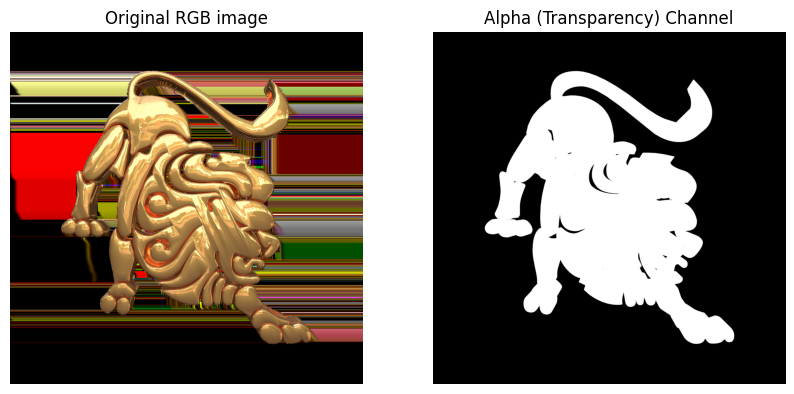

In [6]:
img_bgr = img[..., 0:3]            # Use only three channels - blue, green , red
img_with_alpha = img[..., -1]      # Get only last channel - alpha
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original RGB image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_with_alpha, cmap='gray')
plt.title("Alpha (Transparency) Channel")
plt.axis('off')

plt.show()

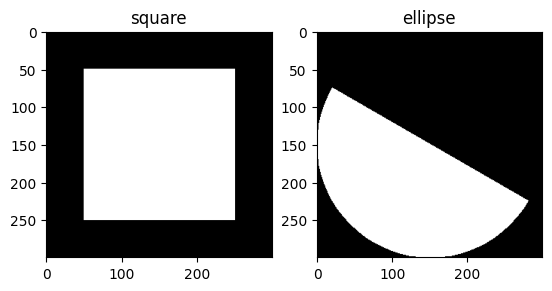

In [7]:
square = np.zeros((300, 300), np.uint8)              # Creating canvas
cv2.rectangle(square, (50, 50), (250, 250), 255,-1)  # 50, 250 coordinates, 255 color, -1 fill with that color

ellipse = np.zeros((300, 300), np.uint8)
cv2.ellipse(ellipse, (150, 150), (150, 150), 30, 0, 180, 255, -1)

plt.subplot(121);plt.imshow(square,cmap='gray');plt.title("square");
plt.subplot(122);plt.imshow(ellipse,cmap='gray');plt.title("ellipse");

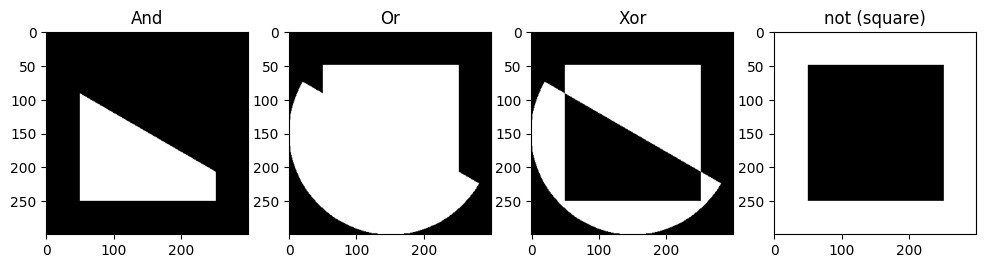

In [8]:
# Shows only where they intersect
bitwise_and = cv2.bitwise_and(square, ellipse)

# Shows where either square or ellipse is
bitwise_or = cv2.bitwise_or(square, ellipse)

# Shows where either exist by itself
bitwise_xor = cv2.bitwise_xor(square, ellipse)

# Shows everything that isn't part of the square
bitwise_not_sq = cv2.bitwise_not(square)

#show
plt.figure(figsize=[12,6])
plt.subplot(245);plt.imshow(bitwise_and,cmap='gray');plt.title("And");
plt.subplot(246);plt.imshow(bitwise_or,cmap='gray');plt.title("Or");
plt.subplot(247);plt.imshow(bitwise_xor,cmap='gray');plt.title("Xor");
plt.subplot(248);plt.imshow(bitwise_not_sq,cmap='gray');plt.title("not (square)");

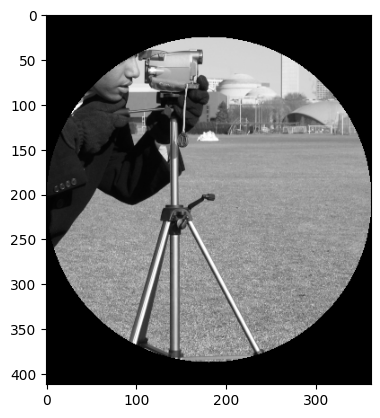

In [9]:
img_1 = cv2.imread("../data/benchmarks/camera.png")
cropped = img_1[100:600 , 150:650]

h, w, c = cropped.shape

mask = np.zeros((h, w, c), np.uint8)
cv2.circle(mask, (w//2, h//2), min(w, h)//2, (255, 255, 255), -1)

output_img = cv2.bitwise_and(cropped, mask)
plt.imshow(output_img[...,::-1])